# Cifar100 Classification using **Convolutional Neural Networks**

## Imports

Import the required libraries for loading the CIFAR-100 dataset, building the CNN model, training it, and visualizing the results.

In [34]:
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
from keras.optimizers import Adam
from keras.models import Sequential
from keras.datasets import cifar100
from keras.losses import SparseCategoricalCrossentropy
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, Softmax, BatchNormalization, Activation

### Dataset Loading
Loads the CIFAR-100 dataset. Using `label_mode='fine'` ensures we target the 100 distinct object classes.


In [3]:
(X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode= 'fine')

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 1343s 8us/step


## Dataset Summary
| Set | Samples | Image Shape | Label Shape |
| :--- | :--- | :--- | :--- |
| **Train** | 50,000 | (32, 32, 3) | (50000, 1) |
| **Test** | 10,000 | (32, 32, 3) | (10000, 1) |

In [4]:
print(f'X_train shape: {X_train.shape}\nX_test: {X_test.shape}\ny_train: {y_train.shape}\ny_test: {y_test.shape}')

X_train shape: (50000, 32, 32, 3)
X_test: (10000, 32, 32, 3)
y_train: (50000, 1)
y_test: (10000, 1)


## Label Shape Update
The target labels were squeezed from shape `(N, 1)` to `(N,)` for compatibility with model training and evaluation.


In [5]:
y_train = np.squeeze(y_train)
y_test = np.squeeze(y_test)
print(f'y_train new shape: {y_train.shape}\ny_test new shape: {y_test.shape}')

y_train new shape: (50000,)
y_test new shape: (10000,)


In [6]:
fine_labels = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee',
    'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus',
    'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch',
    'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant',
    'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo',
    'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard',
    'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree',
    'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy',
    'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road',
    'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk',
    'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar',
    'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone',
    'television', 'tiger', 'tractor', 'train', 'trout', 'tulip',
    'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

## Visualize a CIFAR-100 Image

The `fine_labels` list maps each numeric label to its corresponding class name.  
A selected training image is displayed with its class label.


Enter a image number: 1500


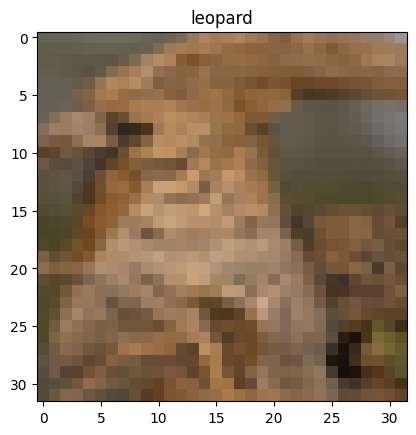

In [7]:
i = int(input('Enter a image number: '))
plt.imshow(X_train[i])
plt.title(fine_labels[y_train[i]]);
plt.savefig(f'{fine_labels[y_train[i]]}_image.png')

## Data Normalization
Pixel values are converted to `float32` and scaled from `[0, 255]` to `[0.0, 1.0]` to accelerate model convergence and improve numerical stability during training.


In [8]:
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

## Experiment 1: Baseline CNN Architecture

In this first experiment, we define a custom `Sequential` model to establish a baseline performance. The architecture consists of two convolutional layers followed by Global Average Pooling and several dense layers with dropout for regularization.

**Configuration:**
- **Architecture**: 2x Conv2D (128, 64), GlobalAveragePooling2D, 3x Dense (128, 128, 64).
- **Optimizer**: Adam (lr=0.001)
- **Loss**: SparseCategoricalCrossentropy (from_logits=True)
- **Epochs**: 40

*Note: Visualizations of training history (accuracy/loss curves) are generated in the next cell.*


In [9]:
model_1 = Sequential([
    Conv2D(128, (3, 3), padding= 'same', activation= 'relu'),
    Conv2D(64, (3, 3), padding= 'same', activation= 'relu'),
    MaxPooling2D(2, 2),
    GlobalAveragePooling2D(),
    Dense(128, activation= 'relu'),
    Dropout(0.3),
    Dense(128, activation= 'relu'),
    Dropout(0.4),
    Dense(64, activation= 'relu'),
    Dropout(0.5),
    Dense(100)
])

model_1.compile(loss= SparseCategoricalCrossentropy(from_logits= True),
                optimizer= Adam(learning_rate= 0.001),
                metrics= ['acc'])

his_1 = model_1.fit(X_train_norm, y_train,
                    batch_size= 32,
                    epochs= 40,
                    validation_split= 0.2,
                    verbose= 2)

Epoch 1/40
1250/1250 - 16s - 13ms/step - acc: 0.0194 - loss: 4.4803 - val_acc: 0.0310 - val_loss: 4.2756
Epoch 2/40
1250/1250 - 8s - 7ms/step - acc: 0.0349 - loss: 4.2458 - val_acc: 0.0527 - val_loss: 4.1044
Epoch 3/40
1250/1250 - 7s - 6ms/step - acc: 0.0528 - loss: 4.0999 - val_acc: 0.0752 - val_loss: 3.9639
Epoch 4/40
1250/1250 - 8s - 6ms/step - acc: 0.0664 - loss: 3.9948 - val_acc: 0.0833 - val_loss: 3.8626
Epoch 5/40
1250/1250 - 8s - 6ms/step - acc: 0.0802 - loss: 3.9110 - val_acc: 0.1017 - val_loss: 3.7767
Epoch 6/40
1250/1250 - 7s - 6ms/step - acc: 0.0882 - loss: 3.8539 - val_acc: 0.1148 - val_loss: 3.6904
Epoch 7/40
1250/1250 - 8s - 6ms/step - acc: 0.0973 - loss: 3.8028 - val_acc: 0.1177 - val_loss: 3.6671
Epoch 8/40
1250/1250 - 8s - 6ms/step - acc: 0.1004 - loss: 3.7678 - val_acc: 0.1296 - val_loss: 3.6318
Epoch 9/40
1250/1250 - 8s - 6ms/step - acc: 0.1093 - loss: 3.7313 - val_acc: 0.1320 - val_loss: 3.5782
Epoch 10/40
1250/1250 - 8s - 6ms/step - acc: 0.1111 - loss: 3.7014 - va

In [45]:
train_1_loss, train_1_acc = model_1.evaluate(X_train_norm, y_train)
test_1_loss, test_1_acc = model_1.evaluate(X_test_norm, y_test)
print(f'Experimen1:\nTrain Accuracy: {train_1_acc * 100:.2f}\nTest Accuracy: {test_1_acc * 100:.2f}\nTrain Loss: {train_1_loss:.2f}\nTest Loss: {test_1_loss:.2}')

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.2430 - loss: 2.9695
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.2290 - loss: 3.0382
Experimen1:
Train Accuracy: 24.30
Test Accuracy: 22.90
Train Loss: 2.97
Test Loss: 3.0


## Experiment 1: Learning Curves

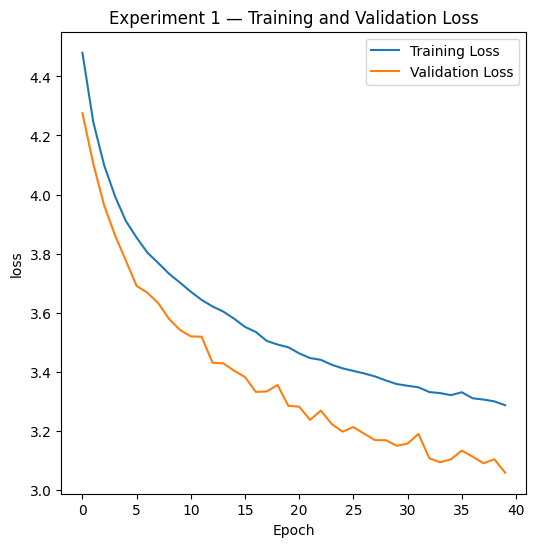

In [11]:
plt.figure(figsize= (6, 6))
plt.plot(his_1.history['loss'], label= 'Training Loss')
plt.plot(his_1.history['val_loss'], label= 'Validation Loss')
plt.title('Experiment 1 — Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('train_1_loss.png')
plt.show()

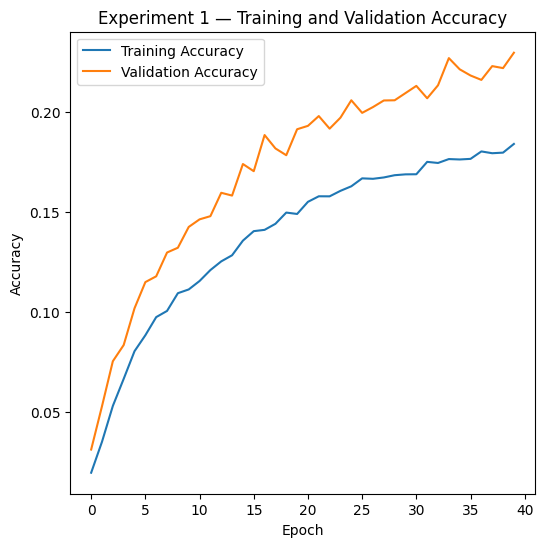

In [12]:
plt.figure(figsize= (6, 6))
plt.plot(his_1.history['acc'], label= 'Training Accuracy')
plt.plot(his_1.history['val_acc'], label= 'Validation Accuracy')
plt.title('Experiment 1 — Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('train_1_accuracy.png')
plt.show()

## Experiment 2: Deeper CNN with 4 Convolutional Layers

In this experiment, network depth is expanded by introducing a second block of two `Conv2D(64)` layers and an additional `MaxPooling2D(2, 2)` layer. Training epochs are also increased from 40 to 60 to allow further feature extraction.

**Configuration:**
- **Architecture**: 2x Conv2D(128) $\rightarrow$ MaxPool $\rightarrow$ 2x Conv2D(64) $\rightarrow$ MaxPool $\rightarrow$ GlobalAveragePooling2D $\rightarrow$ Dense layers (128, 128, 64) with Dropout (0.3, 0.4, 0.5) $\rightarrow$ Dense(100).
- **Optimizer**: Adam (lr=0.001)
- **Loss**: SparseCategoricalCrossentropy (from_logits=True)
- **Batch Size**: 32 | **Epochs**: 60


In [13]:
model_2 = Sequential([
    Conv2D(128, (3, 3), padding= 'same', activation= 'relu'),
    Conv2D(128, (3, 3), padding= 'same', activation= 'relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), padding= 'same', activation= 'relu'),
    Conv2D(64, (3, 3), padding= 'same', activation= 'relu'),
    MaxPooling2D(2, 2),
    GlobalAveragePooling2D(),
    Dense(128, activation= 'relu'),
    Dropout(0.3),
    Dense(128, activation= 'relu'),
    Dropout(0.4),
    Dense(64, activation= 'relu'),
    Dropout(0.5),
    Dense(100)
])

model_2.compile(loss= SparseCategoricalCrossentropy(from_logits= True),
                optimizer= Adam(learning_rate= 0.001),
                metrics= ['acc'])

his_2 = model_2.fit(X_train_norm, y_train,
                    batch_size= 32,
                    epochs= 60,
                    validation_split= 0.2,
                    verbose= 2)

Epoch 1/60
1250/1250 - 19s - 16ms/step - acc: 0.0205 - loss: 4.4570 - val_acc: 0.0310 - val_loss: 4.2766
Epoch 2/60
1250/1250 - 12s - 9ms/step - acc: 0.0311 - loss: 4.2461 - val_acc: 0.0569 - val_loss: 4.1234
Epoch 3/60
1250/1250 - 12s - 10ms/step - acc: 0.0490 - loss: 4.0963 - val_acc: 0.0689 - val_loss: 3.9553
Epoch 4/60
1250/1250 - 12s - 9ms/step - acc: 0.0691 - loss: 3.9436 - val_acc: 0.0962 - val_loss: 3.8063
Epoch 5/60
1250/1250 - 12s - 9ms/step - acc: 0.0828 - loss: 3.8360 - val_acc: 0.1136 - val_loss: 3.6976
Epoch 6/60
1250/1250 - 12s - 9ms/step - acc: 0.0931 - loss: 3.7570 - val_acc: 0.1237 - val_loss: 3.6056
Epoch 7/60
1250/1250 - 12s - 9ms/step - acc: 0.1066 - loss: 3.6846 - val_acc: 0.1389 - val_loss: 3.5336
Epoch 8/60
1250/1250 - 12s - 9ms/step - acc: 0.1141 - loss: 3.6301 - val_acc: 0.1455 - val_loss: 3.4808
Epoch 9/60
1250/1250 - 12s - 9ms/step - acc: 0.1205 - loss: 3.5701 - val_acc: 0.1611 - val_loss: 3.3881
Epoch 10/60
1250/1250 - 12s - 9ms/step - acc: 0.1341 - loss: 3

## 📈 Results & Evaluation Metrics
| Metric / Split | Train Set | Test Set |
| :--- | :--- | :--- |
| **Accuracy** | **13.78%** | **12.37%** |
| **Loss** | **491.99** | **5.60e+02** |

In [44]:
train_2_loss, train_2_acc = model_2.evaluate(X_train_norm, y_train)
test_2_loss, test_2_acc = model_2.evaluate(X_test_norm, y_test)
print(f'Experimen2:\nTrain Accuracy: {train_2_acc * 100:.2f}\nTest Accuracy: {test_2_acc * 100:.2f}\nTrain Loss: {train_2_loss:.2f}\nTest Loss: {test_2_loss:.2}')

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.3719 - loss: 2.2652
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.2890 - loss: 2.9126
Experimen2:
Train Accuracy: 37.19
Test Accuracy: 28.90
Train Loss: 2.27
Test Loss: 2.9


## Experiment 2: Learning Curves

Training and validation accuracy/loss curves are visualized to monitor model convergence and identify potential overfitting or underfitting.


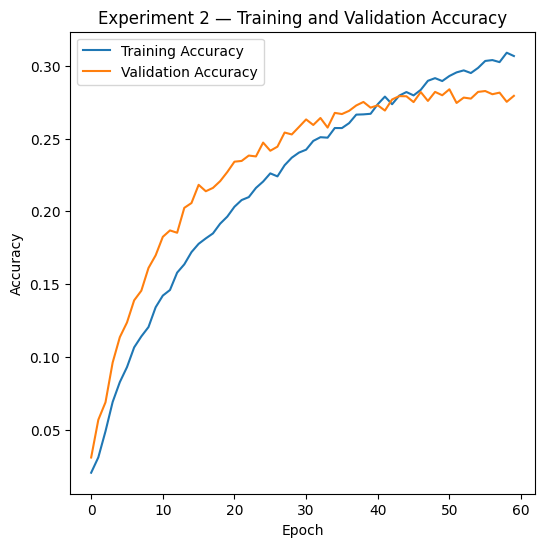

In [25]:
plt.figure(figsize= (6, 6))
plt.plot(his_2.history['acc'], label= 'Training Accuracy')
plt.plot(his_2.history['val_acc'], label= 'Validation Accuracy')
plt.title('Experiment 2 — Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('train_2_accuracy.png')
plt.show()

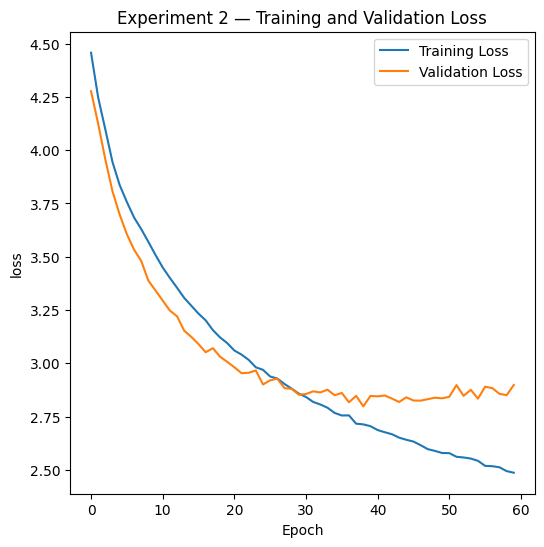

In [24]:
plt.figure(figsize= (6, 6))
plt.plot(his_2.history['loss'], label= 'Training Loss')
plt.plot(his_2.history['val_loss'], label= 'Validation Loss')
plt.title('Experiment 2 — Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('train_2_loss.png')
plt.show()

### Experiment 3: Increasing Dense Capacity and Training Duration

In this experiment, the feature extraction backbone from Experiment 2 is retained (4 convolutional layers with 128 filters each), while the classification head is expanded with higher dense capacity (`Dense(256)` followed by `Dense(128)`). The training duration is also extended to 100 epochs to observe long-term convergence.

**Key Changes:**
- **Expanded Dense Layers**: Replaced earlier shallow fully connected layers with `Dense(256)` and `Dense(128)`.
- **Extended Epochs**: Increased training epochs from 60 to 100 to allow the network more time to learn fine-grained class boundaries.
- **Moderate Regularization**: Dropout rates adjusted to 0.3 and 0.4.

**Architecture Summary:**
- 2x `Conv2D(128, 3x3)` $\rightarrow$ `MaxPooling2D(2x2)`
- 2x `Conv2D(128, 3x3)` $\rightarrow$ `MaxPooling2D(2x2)`
- `GlobalAveragePooling2D()`
- `Dense(256, relu)` $\rightarrow$ `Dropout(0.3)`
- `Dense(128, relu)` $\rightarrow$ `Dropout(0.4)`
- `Dense(100)` (Output Logits)


In [17]:
model_3 = Sequential([
    Conv2D(128, (3, 3), padding= 'same', activation= 'relu'),
    Conv2D(128, (3, 3), padding= 'same', activation= 'relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), padding= 'same', activation= 'relu'),
    Conv2D(128, (3, 3), padding= 'same', activation= 'relu'),
    MaxPooling2D(2, 2),
    GlobalAveragePooling2D(),
    Dense(256, activation= 'relu'),
    Dropout(0.3),
    Dense(128, activation= 'relu'),
    Dropout(0.4),
    Dense(100)
])

model_3.compile(loss= SparseCategoricalCrossentropy(from_logits= True),
                optimizer= Adam(learning_rate= 0.001),
                metrics= ['acc'])

his_3 = model_3.fit(X_train_norm, y_train,
                    batch_size= 32,
                    epochs= 100,
                    validation_split= 0.2,
                    verbose= 2)

Epoch 1/100
1250/1250 - 21s - 17ms/step - acc: 0.0257 - loss: 4.3754 - val_acc: 0.0529 - val_loss: 4.0903
Epoch 2/100
1250/1250 - 13s - 11ms/step - acc: 0.0651 - loss: 3.9723 - val_acc: 0.0937 - val_loss: 3.7832
Epoch 3/100
1250/1250 - 13s - 11ms/step - acc: 0.1057 - loss: 3.7151 - val_acc: 0.1321 - val_loss: 3.6141
Epoch 4/100
1250/1250 - 13s - 11ms/step - acc: 0.1420 - loss: 3.5099 - val_acc: 0.1891 - val_loss: 3.3050
Epoch 5/100
1250/1250 - 13s - 11ms/step - acc: 0.1734 - loss: 3.3278 - val_acc: 0.2155 - val_loss: 3.1202
Epoch 6/100
1250/1250 - 13s - 11ms/step - acc: 0.1994 - loss: 3.1842 - val_acc: 0.2351 - val_loss: 3.0037
Epoch 7/100
1250/1250 - 13s - 11ms/step - acc: 0.2234 - loss: 3.0532 - val_acc: 0.2679 - val_loss: 2.8816
Epoch 8/100
1250/1250 - 13s - 11ms/step - acc: 0.2430 - loss: 2.9422 - val_acc: 0.2758 - val_loss: 2.8364
Epoch 9/100
1250/1250 - 13s - 11ms/step - acc: 0.2661 - loss: 2.8354 - val_acc: 0.2895 - val_loss: 2.7437
Epoch 10/100
1250/1250 - 13s - 11ms/step - acc

In [43]:
train_3_loss, train_3_acc = model_3.evaluate(X_train_norm, y_train)
test_3_loss, test_3_acc = model_3.evaluate(X_test_norm, y_test)
print(f'Experimen3:\nTrain Accuracy: {train_3_acc * 100:.2f}\nTest Accuracy: {test_3_acc * 100:.2f}\nTrain Loss: {train_3_loss:.2f}\nTest Loss: {test_3_loss:.2}')

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.7746 - loss: 1.2041
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.3569 - loss: 4.3796
Experimen3:
Train Accuracy: 77.46
Test Accuracy: 35.69
Train Loss: 1.20
Test Loss: 4.4


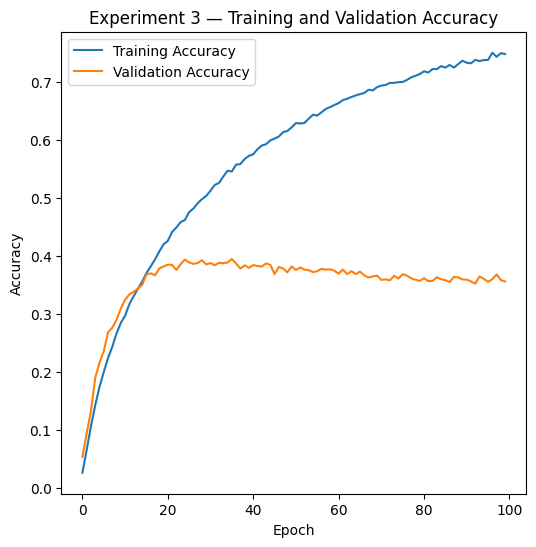

In [22]:
plt.figure(figsize= (6, 6))
plt.plot(his_3.history['acc'], label= 'Training Accuracy')
plt.plot(his_3.history['val_acc'], label= 'Validation Accuracy')
plt.title('Experiment 3 — Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('train_3_accuracy.png')
plt.show()

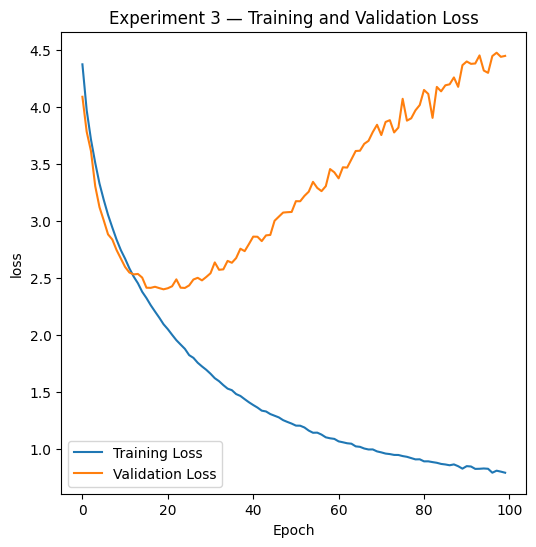

In [21]:
plt.figure(figsize= (6, 6))
plt.plot(his_3.history['loss'], label= 'Training Loss')
plt.plot(his_3.history['val_loss'], label= 'Validation Loss')
plt.title('Experiment 3 — Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('train_3_loss.png')
plt.show()

In [40]:
model_4 = Sequential([
    Conv2D(128, (3, 3), padding= 'same', activation= 'relu'),
    Conv2D(128, (3, 3), padding= 'same', activation= 'relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.2),
    Conv2D(128, (3, 3), padding= 'same', activation= 'relu'),
    Conv2D(128, (3, 3), padding= 'same', activation= 'relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.3),
    Conv2D(256, (3, 3), padding= 'same', activation= 'relu'),
    Conv2D(256, (3, 3), padding= 'same', activation= 'relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.4),
    GlobalAveragePooling2D(),
    Dense(256, activation= 'relu'),
    Dropout(0.25),
    Dense(128, activation= 'relu'),
    Dropout(0.3),
    Dense(100)
])

model_4.compile(loss= SparseCategoricalCrossentropy(from_logits= True),
                optimizer= Adam(learning_rate= 0.0001),
                metrics= ['acc'])

his_4 = model_4.fit(X_train_norm, y_train,
                    batch_size= 32,
                    epochs= 100,
                    verbose= 2)

Epoch 1/100
1563/1563 - 40s - 25ms/step - acc: 0.0538 - loss: 4.3133
Epoch 2/100
1563/1563 - 22s - 14ms/step - acc: 0.1063 - loss: 3.8671
Epoch 3/100
1563/1563 - 21s - 14ms/step - acc: 0.1548 - loss: 3.5333
Epoch 4/100
1563/1563 - 21s - 14ms/step - acc: 0.2045 - loss: 3.2287
Epoch 5/100
1563/1563 - 22s - 14ms/step - acc: 0.2441 - loss: 3.0024
Epoch 6/100
1563/1563 - 21s - 14ms/step - acc: 0.2819 - loss: 2.8147
Epoch 7/100
1563/1563 - 21s - 14ms/step - acc: 0.3110 - loss: 2.6564
Epoch 8/100
1563/1563 - 22s - 14ms/step - acc: 0.3385 - loss: 2.5151
Epoch 9/100
1563/1563 - 21s - 14ms/step - acc: 0.3633 - loss: 2.4040
Epoch 10/100
1563/1563 - 21s - 14ms/step - acc: 0.3861 - loss: 2.2949
Epoch 11/100
1563/1563 - 21s - 14ms/step - acc: 0.4061 - loss: 2.2114
Epoch 12/100
1563/1563 - 21s - 14ms/step - acc: 0.4247 - loss: 2.1199
Epoch 13/100
1563/1563 - 21s - 14ms/step - acc: 0.4445 - loss: 2.0472
Epoch 14/100
1563/1563 - 21s - 14ms/step - acc: 0.4568 - loss: 1.9763
Epoch 15/100
1563/1563 - 41s 

In [50]:
train_4_loss, train_4_acc = model_4.evaluate(X_train_norm, y_train)
test_4_loss, test_4_acc = model_4.evaluate(X_test_norm, y_test)
print(f'Experimen4:\nTrain Accuracy: {train_4_acc * 100:.2f}\nTest Accuracy: {test_4_acc * 100:.2f}\nTrain Loss: {train_4_loss:.2f}\nTest Loss: {test_4_loss:.2}')

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - acc: 0.9721 - loss: 0.1090
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.6109 - loss: 1.7413
Experimen4:
Train Accuracy: 97.21
Test Accuracy: 61.09
Train Loss: 0.11
Test Loss: 1.7


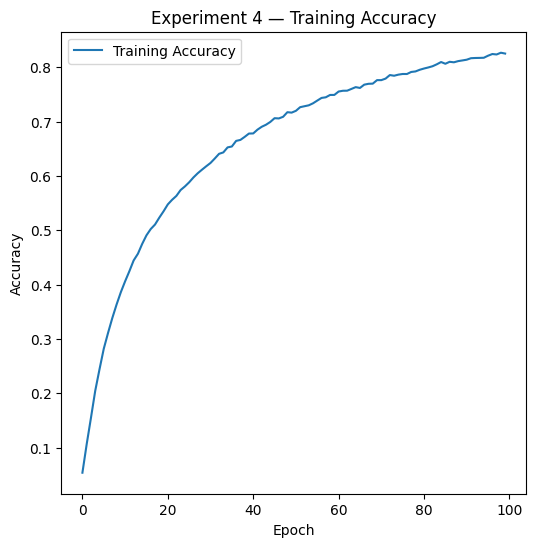

In [51]:
plt.figure(figsize= (6, 6))
plt.plot(his_4.history['acc'], label= 'Training Accuracy')
plt.title('Experiment 4 — Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('train_4_accuracy.png')
plt.show()

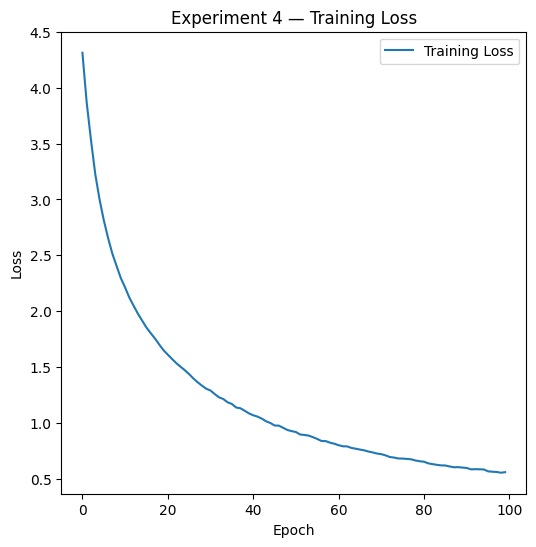

In [52]:
plt.figure(figsize= (6, 6))
plt.plot(his_4.history['loss'], label= 'Training Loss')
plt.title('Experiment 4 — Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('train_4_loss.png')
plt.show()